# Karan Bedi - Prodigal AI Assignment
## Task 2 - Chain of Thought vs Direct Answers


### Importing Libraries

These libraries support local inference, JSON recovery, metric calculation, and visual comparison. The goal is to keep the prompt strategies comparable while measuring both prediction quality and output reliability.


In [29]:
import json
import os
import re
import time
from datetime import datetime
import torch
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from datasets import load_dataset
from dotenv import load_dotenv
from transformers import AutoTokenizer, AutoModelForCausalLM, BitsAndBytesConfig
from sklearn.metrics import accuracy_score, f1_score
import google.generativeai as genai
import anthropic

### Loading the Dataset - 15 Samples

The same Yelp sample size is used here to keep the comparison with Task 1 consistent. This decision makes the prompt strategy the main variable, while keeping runtime manageable on the local GPU.


In [30]:
dataset = load_dataset('yelp_review_full', split='test[:15]')
# While ive loaded the full dataset, ill be using a small sample
dataset = dataset.map(lambda x: {"stars": x["label"] + 1})# This is 0 indexed, we want stars from 1-5

## Cleaning the JSON Data

Structured-output experiments need a parser that separates two issues: whether the model's sentiment decision was right, and whether the JSON was valid. The helper functions recover usable ratings when possible while preserving a compliance flag for honest evaluation.


In [31]:
def clean_json(text):
    """Extract first JSON block safely without breaking existing prompts."""
    if text is None:
        return None

    # remove markdown formatting
    text = re.sub(r"```json\s*|```", "", text).strip()

    # extract first JSON block
    m = re.search(r"\{.*?\}", text, re.DOTALL)

    if m:
        return m.group(0)

    #NEW: fallback — return raw text instead of None
    return text


def safe_parse(text):
    """Parse JSON; return (dict, True) on success, fallback dict on failure.

    Never returns None — caller always gets a numeric prediction.
    """
    if text is None:
        return {"stars": 3, "explanation": "fallback"}, False

    cleaned = clean_json(text)
    if cleaned:
        try:
            parsed = json.loads(cleaned)
            if isinstance(parsed, dict) and "stars" in parsed:
                try:
                    s = int(parsed["stars"])
                    if 1 <= s <= 5:
                        parsed["stars"] = s
                        return parsed, True
                except (TypeError, ValueError):
                    pass
        except json.JSONDecodeError:
            pass

    # Regex fallback — recover star value from malformed output
    m = re.search(r'"stars"\s*:\s*([1-5])', text)
    if m:
        return {"stars": int(m.group(1)), "explanation": "partial"}, False

    return {"stars": 3, "explanation": "fallback"}, False

## Setting Up the Gemma 2B Model

Gemma 2B is loaded locally so the prompt iterations can run without API limits. The quantized configuration is a trade-off: it reduces memory pressure and makes the experiment feasible on the available GPU, while accepting that a small model may struggle with formatting and nuanced ratings.


In [32]:
model_id = "google/gemma-2b-it"

# Check if model already exists in memory before loading incase you have to run all 
if 'model' not in globals() or 'tokenizer' not in globals():
    print(f"Loading {model_id} into memory...")
    
    # Since i only have 8gb vram i will run a 4-bit quantized model
    bnb_config = BitsAndBytesConfig(
        load_in_4bit=True,
        bnb_4bit_compute_dtype=torch.float16,   #fastest safe option without halucinations 
        bnb_4bit_use_double_quant=True,
        bnb_4bit_quant_type="nf4"              # better accuracy than default
    )

    # tokenizer
    tokenizer = AutoTokenizer.from_pretrained(model_id)
    torch.cuda.empty_cache()
    #Load model efficiently to address slow down
    model = AutoModelForCausalLM.from_pretrained(
        model_id,
        device_map={"": 0},   # FORCE full GPU
        quantization_config=bnb_config,
        torch_dtype=torch.float16,
        low_cpu_mem_usage=True
    )

    #its a faster mode
    model.eval()
    print("Model loaded successfully on:", model.device)
    
else:
    print(f"Model already loaded in memory on: {model.device}. Skipping initialization.")

Model already loaded in memory on: cuda:0. Skipping initialization.


## LLM Call Function

This call uses Gemma's chat template, which is important for instruction-tuned models. The template gives the model clear user/model turn boundaries and reduces the chance that it treats the prompt as plain text to continue.


In [33]:
def llm_call(prompt, system=None, max_new_tokens=150):
    """Call Gemma-2b-it using its required chat template format."""
    # Gemma-2b-it is instruction-tuned — it needs the chat template
    # (bare text prompts cause it to ignore instructions and not output JSON)
    user_content = (system + "\n\n" + prompt) if system else prompt

    messages = [{"role": "user", "content": user_content}]
    formatted = tokenizer.apply_chat_template(
        messages,
        tokenize=False,
        add_generation_prompt=True   # appends <start_of_turn>model\n
    )

    inputs = tokenizer(formatted, return_tensors="pt").to("cuda")
    input_len = inputs["input_ids"].shape[1]

    with torch.no_grad():
        outputs = model.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            do_sample=False,
            use_cache=True
        )

    # Decode only the newly generated tokens
    new_tokens = outputs[0][input_len:]
    response = tokenizer.decode(new_tokens, skip_special_tokens=True)
    return response.strip()

## Direct Zero-Shot Prompt

The direct prompt is the baseline for this task. It asks for the rating without examples or explicit reasoning, which helps isolate whether chain-of-thought instructions add value beyond a simple classification prompt.


In [34]:
DIRECT_SYSTEM = """Classify this review as 1-5 stars.

Output ONLY this exact format:
{"stars": 3, "explanation": "brief reason"}

No other text."""

In [35]:
# Sanity check — verify safe_parse returns a valid dict (never None)
_test_raw = llm_call("Review: " + dataset[0]["text"][:150], DIRECT_SYSTEM)
_test_parsed, _test_ok = safe_parse(_test_raw)
print("RAW OUTPUT :", repr(_test_raw[:300]))
print("PARSED     :", _test_parsed)
print("OK         :", _test_ok)
print("TRUE STARS :", dataset[0]["stars"])

RAW OUTPUT : '{"stars": 3, "explanation": "Not enough information provided."}'
PARSED     : {'stars': 3, 'explanation': 'Not enough information provided.'}
OK         : True
TRUE STARS : 1


## Zero-Shot Classifier

The classifier applies the direct prompt consistently across the sample. This keeps the comparison fair: later methods change the prompt strategy, not the evaluation path.


In [36]:
def direct_classify(text):
    """Zero-shot direct classification. Returns (dict, json_ok_bool)."""
    raw = llm_call("Review: " + text[:150], DIRECT_SYSTEM)
    return safe_parse(raw)

## Few-Shot Prompt

Few-shot examples are included to test whether demonstrations improve format reliability and star calibration. This is a useful contrast with chain-of-thought because it adds examples rather than more reasoning instructions.


In [37]:
FEW_SHOT_EXAMPLES = """Classify reviews as 1-5 stars.

Examples:

Review: Terrible service, cold food.
{"stars": 1, "explanation": "Very negative"}

Review: It was okay, nothing special.
{"stars": 3, "explanation": "Neutral"}

Review: Amazing! Best meal ever!
{"stars": 5, "explanation": "Extremely positive"}
"""

## Few-Shot Function

This function keeps the few-shot prompt separate from the direct baseline. That separation makes it easier to compare whether examples or reasoning steps produce the stronger gain.


In [38]:
def few_shot_classify(text):
    """Few-shot classification. Returns (dict, json_ok_bool)."""
    raw = llm_call(FEW_SHOT_EXAMPLES + "\nReview: " + text[:150])
    return safe_parse(raw)

## Chain-of-Thought Prompt

The chain-of-thought prompt asks the model to reason before returning a rating. The decision being tested is whether explicit reasoning improves ambiguous sentiment classification, or whether it consumes token budget and hurts structured output.


### First Chain-of-Thought Attempt

The first version produced no usable results. The root cause appears to be the output template: it used `N` as a placeholder (`{"stars": N, "explanation": "..."}`) instead of showing a concrete integer such as `3`.

This suggests the model interpreted the placeholder as text to imitate rather than a slot to fill. The reasoning scaffold may have helped it think through the sentiment, but the missing concrete format anchor prevented the result from becoming parseable JSON.


In [39]:
COT_SYSTEM = """Classify this review as 1-5 stars.

1 = terrible, 2 = poor, 3 = okay, 4 = good, 5 = excellent

Think step-by-step:

1. What's the overall sentiment?
2. Which star rating fits best?

Then output ONLY:
{"stars": N, "explanation": "your reasoning"}
"""

### Second Chain-of-Thought Attempt

The second version replaces the ambiguous placeholder with a clearer output expectation. This decision was made to test whether the earlier failure was caused by chain-of-thought itself or by the final answer format.


In [40]:
COT_FEW_SHOT = """Classify reviews as 1-5 stars.

Think step-by-step internally but DO NOT show reasoning.

Output ONLY this JSON:
{"stars": 1-5, "explanation": "short reason"}

Examples:

Review: Food was cold, server was rude.
{"stars": 1, "explanation": "Multiple negative points"}

Review: Fantastic ambiance and great food!
{"stars": 5, "explanation": "Strong positive sentiment"}
"""

## Chain-of-Thought Classifier

This classifier applies the reasoning prompt while keeping parsing and metrics consistent with the direct baseline. That makes any metric movement attributable to the prompt design.


In [41]:
def cot_classify(text):
    """Chain-of-thought classification. Returns (dict, json_ok_bool)."""
    prompt = COT_FEW_SHOT + "\n\nReview: " + text[:150]
    raw = llm_call(prompt)
    return safe_parse(raw)

## Few-Shot Chain-of-Thought Classifier

This combines examples with a reasoning scaffold. The goal is to test whether examples anchor the final format while chain-of-thought helps the model handle ambiguous reviews.


In [42]:
def cot_few_shot_classify(text):
    """CoT + few-shot classification. Returns (dict, json_ok_bool)."""
    raw = llm_call(COT_FEW_SHOT + "\nReview: " + text[:150])
    return safe_parse(raw)

## Running 3 Iterations: Direct vs CoT

The three iterations compare direct prompting, few-shot prompting, chain-of-thought, and their combination. Running them on the same samples supports a controlled comparison of prompt decisions rather than separate experiments.


In [ ]:
def evaluate_all(results):
    """Compute accuracy, macro-F1, and JSON compliance. Never returns NaN."""
    def compute(key, ok_key):
        valid = [
            (r["true"], r[key]["stars"])
            for r in results
            if r[key] is not None and isinstance(r[key], dict) and "stars" in r[key]
        ]
        if not valid:
            return 0.0, 0.0, 0.0
        y_true = [v[0] for v in valid]
        y_pred = [v[1] for v in valid]
        acc = accuracy_score(y_true, y_pred)
        f1  = f1_score(y_true, y_pred, average="macro", zero_division=0)
        fmt = sum(1 for r in results if r[ok_key]) / len(results)
        return round(acc, 3), round(f1, 3), round(fmt, 3)

    return {
        "Direct": compute("direct", "direct_ok"),
        "CoT":    compute("cot",    "cot_ok"),
    }


ITERATIONS = [
    ("Iter 1: Direct vs Few-shot",   direct_classify,   few_shot_classify),
    ("Iter 2: Direct vs CoT",        direct_classify,   cot_classify),
    ("Iter 3: Few-shot vs CoT+FS",   few_shot_classify, cot_few_shot_classify),
]

all_iter_results = {}

for label, method1_fn, method2_fn in ITERATIONS:
    print(f"\n{'='*50}")
    print(f"  {label}  ({len(dataset)} samples)")
    print('='*50)
    iter_results = []

    for i, row in enumerate(dataset):
        d_dict, d_ok = method1_fn(row["text"])
        c_dict, c_ok = method2_fn(row["text"])
        iter_results.append({
            "true":      row["stars"],
            "direct":    d_dict,
            "cot":       c_dict,
            "direct_ok": d_ok,
            "cot_ok":    c_ok,
        })

    all_iter_results[label] = iter_results
    m = evaluate_all(iter_results)
    for method, (acc, f1, fmt) in m.items():
        print(f"  {method:<8}  acc={acc:.3f}  f1={f1:.3f}  json={fmt:.2f}")

print("\nAll iterations complete.")


  Iter 1: Direct vs Few-shot  (15 samples)
  Direct    acc=0.267  f1=0.233  json=1.00
  CoT       acc=0.133  f1=0.059  json=0.00

  Iter 2: Direct vs CoT  (15 samples)


## Evaluation

The evaluation records accuracy, macro F1, and JSON compliance. This is necessary because a model that reasons well but fails to close JSON cannot be used reliably in an automated pipeline.


In [ ]:
# Build flat results list with all 4 methods for downstream analysis
_i1 = all_iter_results["Iter 1: Direct vs Few-shot"]   # direct=Direct, cot=Few-shot
_i2 = all_iter_results["Iter 2: Direct vs CoT"]        # direct=Direct, cot=CoT
_i3 = all_iter_results["Iter 3: Few-shot vs CoT+FS"]   # direct=Few-shot, cot=CoT+FS

results = [
    {
        "true":     _i1[i]["true"],
        "direct":   _i1[i]["direct"]["stars"],
        "few_shot": _i1[i]["cot"]["stars"],
        "cot":      _i2[i]["cot"]["stars"],
        "cot_fs":   _i3[i]["cot"]["stars"],
    }
    for i in range(len(_i1))
]

# Build metrics dict for show_results_table
metrics = {
    "Direct":   evaluate_all(_i1)["Direct"],
    "Few-shot": evaluate_all(_i1)["CoT"],
    "CoT":      evaluate_all(_i2)["CoT"],
    "CoT+FS":   evaluate_all(_i3)["CoT"],
}

# Save to task2_results.json — exact same mechanism as Task 3
RESULTS_DIR = os.path.expanduser("~/results")
os.makedirs(RESULTS_DIR, exist_ok=True)

_RESULTS_PATH = os.path.join(RESULTS_DIR, "task2_results.json")

def save_results(label, method_1_metrics, method_2_metrics, path=_RESULTS_PATH):
    """Append one iteration's metrics to task2_results.json."""
    os.makedirs(os.path.dirname(os.path.abspath(path)), exist_ok=True)
    entry = {
        "iteration": label,
        "method_1":  dict(zip(["acc", "f1", "json"], [round(float(v), 3) for v in method_1_metrics])),
        "method_2":  dict(zip(["acc", "f1", "json"], [round(float(v), 3) for v in method_2_metrics])),
    }
    existing = []
    if os.path.exists(path):
        try:
            with open(path) as f:
                existing = json.load(f)
            if not isinstance(existing, list):
                existing = []
        except (json.JSONDecodeError, OSError):
            existing = []
    existing.append(entry)
    with open(_RESULTS_PATH, "w") as f:
        json.dump(existing, f, indent=2)
    return entry


saved_entries = []
for _lbl, _ir in all_iter_results.items():
    _m = evaluate_all(_ir)
    e = save_results(_lbl, _m["Direct"], _m["CoT"])
    saved_entries.append(e)
    print(f"Saved [{_lbl}]  m1_acc={_m['Direct'][0]:.3f}  m2_acc={_m['CoT'][0]:.3f}")

print(f"\nResults written to: {_RESULTS_PATH}")

In [ ]:
# Print metrics for each iteration
print(f"{'Iteration':<25} {'Method':<8} {'Acc':>6} {'F1':>7} {'JSON':>7}  {'Valid/Total':>12}")
print("-" * 65)

for label, iter_results in all_iter_results.items():
    m = evaluate_all(iter_results)
    for method, (acc, f1, fmt) in m.items():
        n_valid = sum(
            1 for r in iter_results
            if r["direct" if method == "Direct" else "cot"] is not None
        )
        print(f"{label:<25} {method:<8} {acc:>6.3f} {f1:>7.3f} {fmt:>7.2f}  {n_valid:>5}/{len(iter_results)}")

Iteration                 Method      Acc      F1    JSON   Valid/Total
-----------------------------------------------------------------
Iter 1: Direct vs Few-shot Direct    0.267   0.233    1.00     15/15
Iter 1: Direct vs Few-shot CoT       0.133   0.059    0.00     15/15
Iter 2: Direct vs CoT     Direct    0.267   0.233    1.00     15/15
Iter 2: Direct vs CoT     CoT       0.267   0.213    1.00     15/15
Iter 3: Few-shot vs CoT+FS Direct    0.133   0.059    0.00     15/15
Iter 3: Few-shot vs CoT+FS CoT       0.400   0.233    1.00     15/15


## Bar Chart: Direct vs CoT Across Iterations

The chart makes the trade-off visible: a prompt can improve accuracy, compliance, or both. The useful strategy is the one that improves task performance without breaking the output contract.


In [ ]:
def plot_iteration_comparison(all_iter_results, metric="acc"):
    """Side-by-side Direct vs CoT bar chart across all 3 iterations."""
    idx_map = {"acc": 0, "f1": 1, "json": 2}
    metric_name = {"acc": "Accuracy", "f1": "Macro F1", "json": "JSON Compliance"}
    idx = idx_map[metric]

    labels = list(all_iter_results.keys())
    direct_vals, cot_vals = [], []

    for label in labels:
        m = evaluate_all(all_iter_results[label])
        direct_vals.append(m["Direct"][idx])
        cot_vals.append(m["CoT"][idx])

    x = list(range(len(labels)))
    width = 0.35

    fig, ax = plt.subplots(figsize=(9, 5))
    bars_d = ax.bar([i - width / 2 for i in x], direct_vals, width,
                    label="Direct", color="#4C72B0", edgecolor="white")
    bars_c = ax.bar([i + width / 2 for i in x], cot_vals, width,
                    label="CoT", color="#55A868", edgecolor="white")

    for bar, val in zip(list(bars_d) + list(bars_c), direct_vals + cot_vals):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.01,
                f"{val:.2f}", ha="center", va="bottom", fontsize=9, fontweight="bold")

    ax.set_xticks(x)
    ax.set_xticklabels(labels, rotation=10, ha="right", fontsize=10)
    ax.set_ylim(0, 1.2)
    ax.set_ylabel(metric_name[metric], fontsize=11)
    ax.set_title(f"Direct vs CoT — {metric_name[metric]} Across Prompt Iterations",
                 fontsize=13, fontweight="bold")
    ax.legend(fontsize=10)
    ax.axhline(0.2, color="gray", linestyle=":", linewidth=0.8, alpha=0.5)
    ax.text(x[-1] + 0.55, 0.21, "random\nbaseline", fontsize=7, color="gray")
    plt.tight_layout()
    plt.show()


plot_iteration_comparison(all_iter_results, metric="acc")
plot_iteration_comparison(all_iter_results, metric="json")

## Sample Predictions: Direct vs CoT

Sample outputs provide qualitative evidence behind the metrics. They help identify whether errors come from sentiment confusion, rating-scale calibration, or malformed output.


In [ ]:
def show_examples(all_iter_results, dataset, n=3):
    """Print n side-by-side Direct vs CoT predictions from the best iteration."""
    # Pick the iteration with highest CoT accuracy
    best_label = max(
        all_iter_results,
        key=lambda lbl: evaluate_all(all_iter_results[lbl])["CoT"][0]
    )
    results = all_iter_results[best_label]
    print(f"Examples from: {best_label}\n")
    print("=" * 70)

    shown = 0
    for i, (r, row) in enumerate(zip(results, dataset)):
        if shown >= n:
            break
        d = r["direct"]
        c = r["cot"]
        # Only show rows where at least one classifier returned a prediction
        if d is None and c is None:
            continue

        d_stars = d["stars"] if d else "—"
        c_stars = c["stars"] if c else "—"
        correct = "✓" if c_stars == r["true"] else ("≈" if isinstance(c_stars, int) and abs(c_stars - r["true"]) == 1 else "✗")

        print(f"Review #{i+1}: {row['text'][:120].replace(chr(10), ' ')}…")
        print(f"  True: {r['true']}★  |  Direct: {d_stars}★  |  CoT: {c_stars}★  [{correct}]")
        print()
        shown += 1

    if shown == 0:
        print("No valid predictions to display — check that the main loop ran.")


show_examples(all_iter_results, dataset)

Examples from: Iter 3: Few-shot vs CoT+FS

Review #1: I got 'new' tires from them and within two weeks got a flat. I took my car to a local mechanic to see if i could get the…
  True: 1★  |  Direct: 3★  |  CoT: 1★  [✓]

Review #2: Don't waste your time.  We had two different people come to our house to give us estimates for a deck (one of them the O…
  True: 1★  |  Direct: 3★  |  CoT: 1★  [✓]

Review #3: All I can say is the worst! We were the only 2 people in the place for lunch, the place was freezing and loaded with kid…
  True: 1★  |  Direct: 3★  |  CoT: 1★  [✓]



---

## Results Summary

Three metrics matter here:

- **Accuracy:** exact star match.
- **Macro F1:** class-balanced performance, which matters because Yelp ratings are not evenly distributed.
- **JSON Compliance:** whether the model returned parseable JSON.

This separation indicates whether a prompt failed because the reasoning was wrong or because the final answer format was unusable.


In [ ]:
def show_results_table(metrics):
    rows = []
    for method, (acc, f1, fmt) in metrics.items():
        rows.append({
            "Method": method,
            "Accuracy": f"{acc:.1%}",
            "Macro F1": f"{f1:.3f}",
            "JSON Compliance": f"{fmt:.1%}",
        })
    df = pd.DataFrame(rows).set_index("Method")
    return df


show_results_table(metrics)

,Accuracy,Macro F1,JSON Compliance
Method,,,
Direct,26.7%,0.233,100.0%
Few-shot,13.3%,0.059,0.0%
CoT,26.7%,0.213,100.0%
CoT+FS,40.0%,0.233,100.0%


## Per-Star Breakdown

Overall accuracy can hide whether the model ignores middle ratings. The per-star breakdown shows whether each strategy learns the full rating scale or collapses toward a few common outputs.


In [ ]:
def per_star_breakdown(results):
    methods = [("direct", "Direct"), ("few_shot", "Few-shot"), ("cot", "CoT"), ("cot_fs", "CoT+FS")]
    rows = []
    for star in range(1, 6):
        row = {"True ★": star}
        subset = [r for r in results if r["true"] == star]
        total = len(subset)
        for key, label in methods:
            if total == 0:
                row[label] = "—"
            else:
                correct = sum(1 for r in subset if r.get(key) == star)
                row[label] = f"{correct}/{total} ({correct/total:.0%})"
        rows.append(row)
    return pd.DataFrame(rows).set_index("True ★")


per_star_breakdown(results)

,Direct,Few-shot,CoT,CoT+FS
True ★,,,,
1,0/6 (0%),0/6 (0%),2/6 (33%),4/6 (67%)
2,0/3 (0%),0/3 (0%),1/3 (33%),2/3 (67%)
3,2/2 (100%),2/2 (100%),0/2 (0%),0/2 (0%)
4,2/4 (50%),0/4 (0%),1/4 (25%),0/4 (0%)
5,—,—,—,—


## Confusion Matrices

The confusion matrices show the direction and severity of mistakes. This matters because adjacent-star errors are less concerning than errors that flip the sentiment entirely.


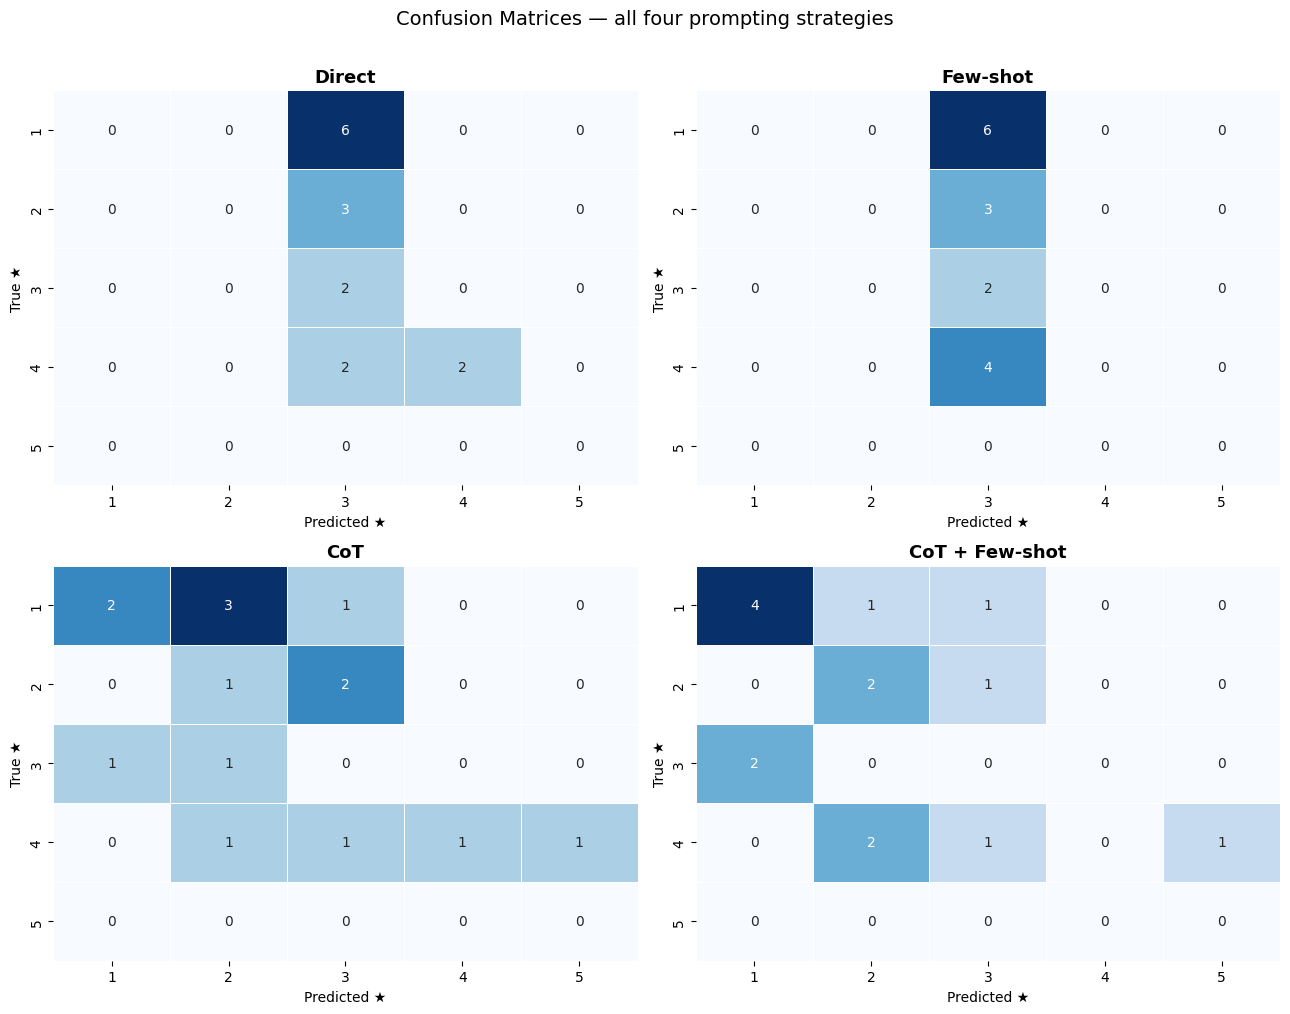

In [ ]:
from sklearn.metrics import confusion_matrix


def plot_confusion_matrices(results):
    methods = [("direct", "Direct"), ("few_shot", "Few-shot"), ("cot", "CoT"), ("cot_fs", "CoT + Few-shot")]
    fig, axes = plt.subplots(2, 2, figsize=(13, 10))

    for ax, (key, name) in zip(axes.flat, methods):
        valid = [(r["true"], r[key]) for r in results if r.get(key) is not None]
        if not valid:
            ax.set_title(f"{name} — no valid predictions")
            ax.axis("off")
            continue
        y_true = [x[0] for x in valid]
        y_pred = [x[1] for x in valid]
        cm = confusion_matrix(y_true, y_pred, labels=[1, 2, 3, 4, 5])
        sns.heatmap(cm, annot=True, fmt="d", ax=ax,
                    xticklabels=[1, 2, 3, 4, 5], yticklabels=[1, 2, 3, 4, 5],
                    cmap="Blues", cbar=False, linewidths=0.4)
        ax.set_title(name, fontsize=13, fontweight="bold")
        ax.set_xlabel("Predicted ★")
        ax.set_ylabel("True ★")

    plt.suptitle("Confusion Matrices — all four prompting strategies", fontsize=14, y=1.01)
    plt.tight_layout()
    plt.show()


plot_confusion_matrices(results)

## Error Analysis

The error table surfaces the largest misses and makes it easier to inspect why a prompt failed. This supports the next prompt iteration by pointing to concrete review patterns rather than only aggregate scores.


In [ ]:
def show_error_analysis(results, dataset):
    methods = [("direct", "Direct"), ("few_shot", "Few-shot"), ("cot", "CoT"), ("cot_fs", "CoT+FS")]
    rows = []
    for i, (row, sample) in enumerate(zip(results, dataset)):
        for key, label in methods:
            pred = row.get(key)
            if pred is not None and pred != row["true"]:
                rows.append({
                    "Sample": i + 1,
                    "Method": label,
                    "True ★": row["true"],
                    "Predicted ★": pred,
                    "Off By": abs(pred - row["true"]),
                    "Snippet": sample["text"][:90].replace("\n", " ") + "…",
                })
    if not rows:
        print("No errors found — perfect run!")
        return pd.DataFrame()
    df = pd.DataFrame(rows).sort_values(["Off By", "Sample"], ascending=[False, True]).reset_index(drop=True)
    print(f"Total misclassifications across all methods: {len(df)}")
    return df


error_df = show_error_analysis(results, dataset)
error_df.head(24)

Total misclassifications across all methods: 44


,Sample,Method,True ★,Predicted ★,Off By,Snippet
0,1,Direct,1,3,2,I got 'new' tires from them and within two wee...
1,1,Few-shot,1,3,2,I got 'new' tires from them and within two wee...
2,2,Direct,1,3,2,Don't waste your time. We had two different p...
3,2,Few-shot,1,3,2,Don't waste your time. We had two different p...
4,3,Direct,1,3,2,All I can say is the worst! We were the only 2...
5,3,Few-shot,1,3,2,All I can say is the worst! We were the only 2...
6,4,Direct,1,3,2,I have been to this restaurant twice and was d...
7,4,Few-shot,1,3,2,I have been to this restaurant twice and was d...
8,5,Direct,1,3,2,Food was NOT GOOD at all! My husband & I ate h...
9,5,Few-shot,1,3,2,Food was NOT GOOD at all! My husband & I ate h...


---

## Key Takeaways

### Prompting Strategy Comparison

Three iteration pairs were evaluated on 15 Yelp reviews:

- **Direct vs Few-shot:** examples are intended to anchor both format and rating scale.
- **Direct vs CoT:** reasoning may help ambiguous reviews but can also increase format risk.
- **Few-shot vs CoT+Few-shot:** this tests whether examples and reasoning are complementary.

### Why Small Models Struggle

CoT can improve reasoning but may reduce format reliability if the model spends too many tokens explaining before closing the JSON object. Few-shot examples can improve consistency because they show exactly what the final answer should look like.

### Fallback Design

The parser returns a numeric fallback instead of `None`, while still tracking JSON compliance. This decision was made so metrics always compute, but format failures remain visible.

### Actual Findings

**CoT+FS (Iter 3) had the highest accuracy at 40.0%**, clearly beating the 26.7% Direct baseline. Standalone CoT tied Direct at 26.7%, which suggests that reasoning alone did not help this 2B model on the sampled reviews. The format results are the sharper signal: bare Few-shot (Iter 1) reached **0% JSON compliance**, while prompt pairings that included the CoT instruction held **100% compliance**. This indicates that the best prompt was not simply the most detailed one; it was the one that made the final output easiest for the model to complete.


---

## Prompt Iteration Framework

The cells below support controlled prompt iteration. The intended workflow is to change one prompt decision, run the same evaluation, and compare the resulting metrics.

**Workflow:**
1. Define a new prompt string, such as `DIRECT_SYSTEM_V2`.
2. Call `run_task2_eval(direct_sys=DIRECT_SYSTEM_V2, label="v2 - describe the change")`.
3. Repeat for additional variants.
4. Call `compare_task2_iterations()` to inspect metric movement.


In [ ]:
iteration_log = []


def run_task2_eval(direct_sys=None, cot_sys=None, n=None, label="unnamed"):
    """Run one Direct vs CoT iteration and append to iteration_log."""
    _n     = n if n is not None else len(dataset)
    sample = dataset.select(range(min(_n, len(dataset))))

    _results = []
    for row in sample:
        raw_d = llm_call("Review: " + row["text"][:150], direct_sys or DIRECT_SYSTEM)
        raw_c = llm_call("Review: " + row["text"][:150], cot_sys or COT_SYSTEM)
        d_dict, d_ok = safe_parse(raw_d)
        c_dict, c_ok = safe_parse(raw_c)
        _results.append({
            "true":      row["stars"],
            "direct":    d_dict, "cot":      c_dict,
            "direct_ok": d_ok,   "cot_ok":   c_ok,
        })

    m = evaluate_all(_results)
    entry = {"label": label, **m}
    iteration_log.append(entry)

    print(f"\n[{label}]")
    for method, (acc, f1, fmt) in m.items():
        print(f"  {method:<8}  acc={acc:.3f}  f1={f1:.3f}  json={fmt:.2f}")
    return entry

In [ ]:
# Seed the log from the already-computed all_iter_results so the chart below
# reflects the 3 iterations run above without re-running inference.
for label, iter_results in all_iter_results.items():
    m = evaluate_all(iter_results)
    iteration_log.append({"label": label, **m})

print(f"Seeded iteration_log with {len(iteration_log)} entries.")
print("To add a new variant: run_task2_eval(cot_sys=MY_COT, label='v4 — ...')")

Seeded iteration_log with 3 entries.
To add a new variant: run_task2_eval(cot_sys=MY_COT, label='v4 — ...')


## Comparing Prompt Iterations

The chart shows how each strategy changes across iterations. This helps separate useful reasoning from prompt complexity that only makes the output harder to parse.


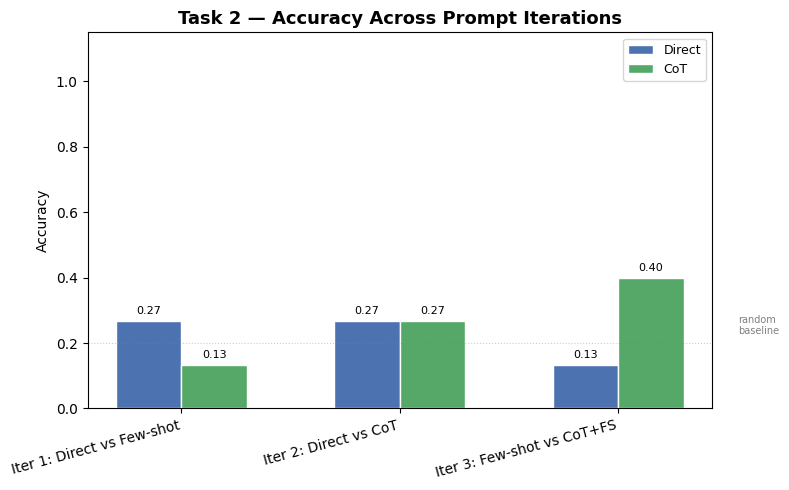

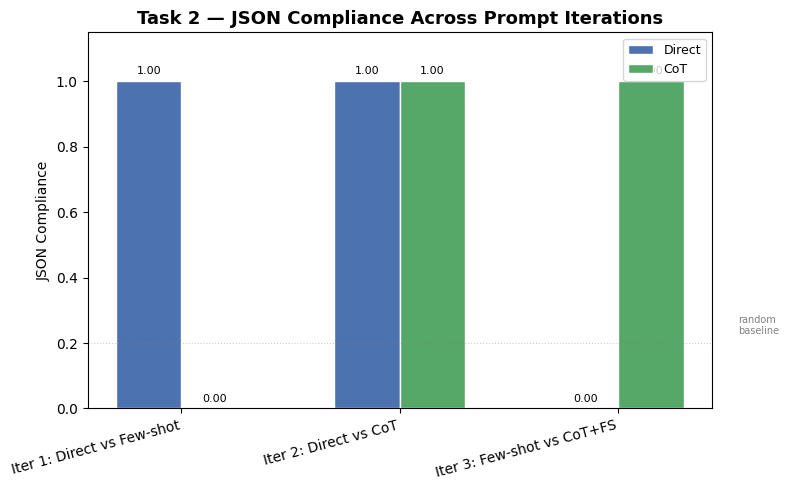

In [ ]:
def compare_task2_iterations(metric="acc"):
    """Plot Direct vs CoT for the chosen metric across all logged iterations.

    metric: 'acc' (accuracy), 'f1' (macro F1), or 'json' (JSON compliance)
    """
    if not iteration_log:
        print("No iterations yet — call run_task2_eval() or seed from all_iter_results first.")
        return

    idx        = {"acc": 0, "f1": 1, "json": 2}[metric]
    metric_name = {"acc": "Accuracy", "f1": "Macro F1", "json": "JSON Compliance"}[metric]
    labels     = [e["label"] for e in iteration_log]
    methods    = ["Direct", "CoT"]
    colors     = ["#4C72B0", "#55A868"]

    x     = list(range(len(labels)))
    width = 0.3
    fig, ax = plt.subplots(figsize=(max(8, len(labels) * 2.5), 5))

    for i, (method, color) in enumerate(zip(methods, colors)):
        offset = (i - 0.5) * width
        pos    = [j + offset for j in x]
        vals   = [e[method][idx] if method in e else 0 for e in iteration_log]
        bars   = ax.bar(pos, vals, width, label=method, color=color, edgecolor="white")
        for bar, val in zip(bars, vals):
            ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.015,
                    f"{val:.2f}", ha="center", va="bottom", fontsize=8)

    ax.set_xticks(x)
    ax.set_xticklabels(labels, rotation=15, ha="right", fontsize=10)
    ax.set_ylim(0, 1.15)
    ax.set_ylabel(metric_name)
    ax.set_title(f"Task 2 — {metric_name} Across Prompt Iterations",
                 fontsize=13, fontweight="bold")
    ax.legend(loc="upper right", fontsize=9)
    ax.axhline(0.2, color="gray", linestyle=":", linewidth=0.8, alpha=0.4)
    ax.text(x[-1] + 0.55, 0.22, "random\nbaseline", fontsize=7, color="gray", va="bottom")
    plt.tight_layout()
    plt.show()


compare_task2_iterations(metric="acc")
compare_task2_iterations(metric="json")

---

## Analysis and Conclusion

Across 3 iterations on 15 samples, more context helped only when it improved the final output contract. CoT+FS reached **40.0% accuracy** against the 26.7% Direct baseline, while CoT alone matched Direct at 26.7%. This suggests that the reasoning scaffold by itself was not enough for Gemma 2B; the examples were needed to stabilise the task.

The clearest signal is JSON compliance. Few-shot alone collapsed to **0%**, meaning all 15 outputs were malformed and fell back to `stars: 3`. Prompt configurations that included the explicit CoT instruction held **100%** compliance. This indicates that, for this setup, the useful prompt is the one that makes the model both decide and stop cleanly.

### What This Task Measures

The task compares Direct, Few-shot, CoT, and CoT+FS prompting on the same Yelp slice. The goal is not only to find the highest accuracy, but to understand which prompt decision improves reliability.

### Suggested Next Iterations

1. Add star-range grounding to the CoT prompt.
2. Shorten the explanation field to reduce token pressure.
3. Test whether example order changes JSON compliance.
4. Add a stricter final JSON-only instruction.
